# Adjoint method on the actual UWM denoiser — policy mode + LoRA fine-tuning

LoRA variant of [adjoint_denoiser_policy.ipynb](./adjoint_denoiser_policy.ipynb). Drives the same `terminal_loss = ½·mean(a²)` to zero with an Adam loop on the discrete adjoint gradient (Section 1 of the base notebook), but instead of touching the 172M base parameters we only update a thin LoRA adapter (~1.6% trainable with `r=8, all-linear`).

**Why combine adjoint + LoRA — they're orthogonal.**

| Cost | Plain FT | Adjoint only | Adjoint + LoRA |
|---|---|---|---|
| Activation cache | full rollout | one diffusion step | one diffusion step |
| `p.grad` tensors | ~700 MB fp32 | ~700 MB fp32 | **~11 MB** |
| Adam state (m, v) | ~1.4 GB fp32 | ~1.4 GB fp32 | **~22 MB** |

The adjoint kills *activation* memory by walking the rollout backward one step at a time; LoRA kills *parameter-grad / optimizer-state* memory by making 98%+ of the model frozen. Compute savings are modest (the input-VJP that propagates the state cotangent is unchanged), but the parameter-VJP and the optimizer step shrink with the trainable param count.

**Forgetting story.** `½·mean(a²)` is deliberately adversarial — it tells the model *predict zero actions for everything*. Under full FT (the base notebook) this collapses the action head visibly in 200 steps. With LoRA the same 200 steps move actions less aggressively, *and* `disable_adapter()` recovers the pretrained policy bit-exact regardless of how aggressively the adapter has been trained — a guarantee full FT cannot give. We demonstrate both at the end.

In [1]:
import sys, time, math, copy
sys.path.insert(0, "/home/mim-server/projects/rooholla/dreamerV4-UWM")

import torch
from hydra import initialize_config_dir, compose
from torch.nn.functional import interpolate

from dreamerv4uwm.models.utils import load_denoiser, load_tokenizer
from dreamerv4uwm.datasets import ShardedHDF5Dataset
from dreamerv4uwm.sampling import get_noise_index

torch.manual_seed(0)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
DTYPE = torch.float32      # full precision for grad verification (no autocast)

In [2]:
CFG_DIR = "/home/mim-server/projects/rooholla/dreamerV4-UWM/scripts/config"
DATA_PATH = "/home/mim-server/datasets/pushT/sharded"
DYNAMICS_CKPT = "/home/mim-server/projects/rooholla/dreamerV4-UWM/checkpoints/dynamics/pushT/final/joint-model/v1/432360.pt"
TOKENIZER_CKPT = "/home/mim-server/projects/rooholla/dreamerV4-UWM/checkpoints/tokenizer_ckpts/pushT.pt"

with initialize_config_dir(version_base=None, config_dir=CFG_DIR):
    cfg = compose(config_name="dynamics/pushT.yaml")

cfg.denoiser.layer_types = ["spatial", "temporal", "spatial", "temporal"]
cfg.dynamics_ckpt = DYNAMICS_CKPT
cfg.tokenizer_ckpt = TOKENIZER_CKPT

denoiser = load_denoiser(cfg, device, max_num_forward_steps=300).to(DTYPE).eval()
tokenizer = load_tokenizer(cfg, device, max_num_forward_steps=300).to(DTYPE).eval()

# tokenizer always frozen
for p in tokenizer.parameters():
    p.requires_grad_(False)

print(f"denoiser params (pre-LoRA): {sum(p.numel() for p in denoiser.parameters()):,}")

/home/mim-server/miniconda3/envs/dreamerv4/lib/python3.11/site-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'dynamics/pushT.yaml': Defaults list is missing `_self_`. See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)


denoiser params (pre-LoRA): 172,530,434


## Wrap denoiser with PEFT LoRA

`target_modules="all-linear"` replaces every `nn.Linear` in the denoiser with a `LoraLinear` (frozen `W` + trainable low-rank `B·A`): attention (`W_q/W_k/W_v/W_o`), FFN (`up/gate/down`), the head projectors (`obs_projector`, `action_projector`, `latent_projector`, `action_input_proj`), and the diff-control combiners. For a smaller adapter, drop to `["W_q", "W_v"]` (conservative) or `["W_q", "W_k", "W_v", "W_o"]` (attention-only). PEFT initialises `B = 0` so the adapter is a no-op at the start — the pre-training rollout below is bit-identical to the base denoiser.

In [3]:
from peft import LoraConfig, get_peft_model

lora_cfg = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.0,
    bias="none",
    target_modules="all-linear",
)
denoiser = get_peft_model(denoiser, lora_cfg)
denoiser = denoiser.to(DTYPE).eval()
denoiser.print_trainable_parameters()

trainable = [p for p in denoiser.parameters() if p.requires_grad]
n_train_params = sum(p.numel() for p in trainable)
n_total_params = sum(p.numel() for p in denoiser.parameters())
print(f"trainable tensors: {len(trainable)} | "
      f"trainable elements: {n_train_params:,} / {n_total_params:,} "
      f"({100*n_train_params/n_total_params:.3f}%)")

trainable params: 2,863,648 || all params: 175,394,082 || trainable%: 1.6327
trainable tensors: 348 | trainable elements: 2,863,648 / 175,394,082 (1.633%)


In [4]:
dataset = ShardedHDF5Dataset(
    data_dir=DATA_PATH, window_size=64, stride=1,
    split='train', train_fraction=0.9, split_seed=123,
)
batch = dataset[400]
imgs = batch["image"]
acts = batch["action"][:, :cfg.denoiser.n_actions]
imgs = interpolate(imgs, (256, 256)).to(device=device, dtype=DTYPE)[None]

with torch.no_grad():
    latents = tokenizer.encode(imgs)

T_CTX = 4
NUM_PRED_STEPS = 16
NUM_DIFFUSION_STEPS = 4
B = 4

ctx_latents = latents[:B, :T_CTX].to(DTYPE).contiguous()
ctx_actions = acts[:T_CTX].to(device=device, dtype=DTYPE)[None]
ctx_latents = ctx_latents.repeat_interleave(B, dim=0)
ctx_actions = ctx_actions.repeat_interleave(B, dim=0)
print(f"ctx_latents {ctx_latents.shape}, ctx_actions {ctx_actions.shape}")

Train split: 64694 windows from 11 episodes
ctx_latents torch.Size([4, 4, 256, 32]), ctx_actions torch.Size([4, 4, 2])


## Forward sampler with trajectory saving

Same `policy_setup` / `denoiser_call` / `policy_forward_with_traj` as the base notebook. The PEFT wrapper is transparent — `denoiser(...)` chains through `PeftModel → LoraModel → DenoiserWrapper → DreamerV4Denoiser`. We seed the noise (`SEED_FWD`) so the same rollout can be replayed at the end with `disable_adapter()` for a bit-exact comparison.

In [5]:
def policy_setup(ctx_latents, ctx_actions, num_pred_steps, num_diffusion_steps,
                 context_cond_tau=0.9, action_noise_std=1.0):
    B, T_ctx, N_lat, D_lat = ctx_latents.shape
    n_act = ctx_actions.shape[-1]
    T_total = T_ctx + num_pred_steps
    dev, dt = ctx_latents.device, ctx_latents.dtype

    num_noise_levels = cfg.denoiser.num_noise_levels
    tau_cond_idx = get_noise_index(context_cond_tau, num_noise_levels)
    stride = num_noise_levels // num_diffusion_steps
    step_size = 1.0 / num_diffusion_steps
    step_idx_t = torch.zeros((B, T_total), dtype=torch.long, device=dev)

    z_ctx = ((1.0 - context_cond_tau) * torch.randn_like(ctx_latents)
             + context_cond_tau * ctx_latents)
    a_ctx = ((1.0 - context_cond_tau) * action_noise_std * torch.randn_like(ctx_actions)
             + context_cond_tau * ctx_actions)
    z_fut0 = torch.randn(B, num_pred_steps, N_lat, D_lat, device=dev, dtype=dt)
    a_fut0 = action_noise_std * torch.randn(B, num_pred_steps, n_act, device=dev, dtype=dt)

    sigma_schedule, alphas = [], []
    for k in range(num_diffusion_steps):
        tau_idx = k * stride
        tau = tau_idx / num_noise_levels
        sigma = torch.full((B, T_total), tau_idx, dtype=torch.long, device=dev)
        sigma[:, :T_ctx] = tau_cond_idx
        sigma_schedule.append(sigma)
        alphas.append(step_size / max(1.0 - tau, 1e-5))

    return {
        "z_ctx": z_ctx, "a_ctx": a_ctx, "z_fut0": z_fut0, "a_fut0": a_fut0,
        "step_idx_t": step_idx_t, "sigma_schedule": sigma_schedule,
        "alphas": alphas, "T_ctx": T_ctx, "T_total": T_total,
    }


def denoiser_call(z_fut, a_fut, setup, k):
    z = torch.cat([setup["z_ctx"], z_fut], dim=1)
    z_act = torch.cat([setup["a_ctx"], a_fut], dim=1)
    sigma = setup["sigma_schedule"][k]
    z_hat, act_hat = denoiser(
        noisy_act=z_act, noisy_obs=z,
        obs_sigma_idx=sigma, obs_step_idx=setup["step_idx_t"],
        act_sigma_idx=sigma, act_step_idx=setup["step_idx_t"],
    )
    act_hat = act_hat.squeeze(-2)
    Tc = setup["T_ctx"]
    return z_hat[:, Tc:], act_hat[:, Tc:]


@torch.no_grad()
def policy_forward_with_traj(ctx_latents, ctx_actions, num_pred_steps, num_diffusion_steps):
    setup = policy_setup(ctx_latents, ctx_actions, num_pred_steps, num_diffusion_steps)
    z_fut = setup["z_fut0"].clone()
    a_fut = setup["a_fut0"].clone()
    traj_z = [z_fut.clone()]
    traj_a = [a_fut.clone()]
    for k, alpha in enumerate(setup["alphas"]):
        z_hat_fut, a_hat_fut = denoiser_call(z_fut, a_fut, setup, k)
        z_fut = z_fut + alpha * (z_hat_fut - z_fut)
        a_fut = a_fut + alpha * (a_hat_fut - a_fut)
        traj_z.append(z_fut.clone())
        traj_a.append(a_fut.clone())
    return traj_z, traj_a, setup


# Seed the pre-training rollout — same seed is replayed at the end with disable_adapter()
SEED_FWD = 4242
torch.manual_seed(SEED_FWD)
traj_z, traj_a, setup = policy_forward_with_traj(
    ctx_latents, ctx_actions, NUM_PRED_STEPS, NUM_DIFFUSION_STEPS
)
pred_obs = traj_z[-1]
pred_act = traj_a[-1]
print(f"pred_obs {pred_obs.shape}")
print(f"pred_act {pred_act.shape}")
print(f"alphas:  {setup['alphas']}")

pred_obs torch.Size([4, 16, 256, 32])
pred_act torch.Size([4, 16, 2])
alphas:  [0.25, 0.3333333333333333, 0.5, 1.0]


## Pre-training visualization

LoRA at init has `B = 0`, so the rollout below is identical to the base denoiser. Snapshot of what we'll compare against when checking `disable_adapter()` later.

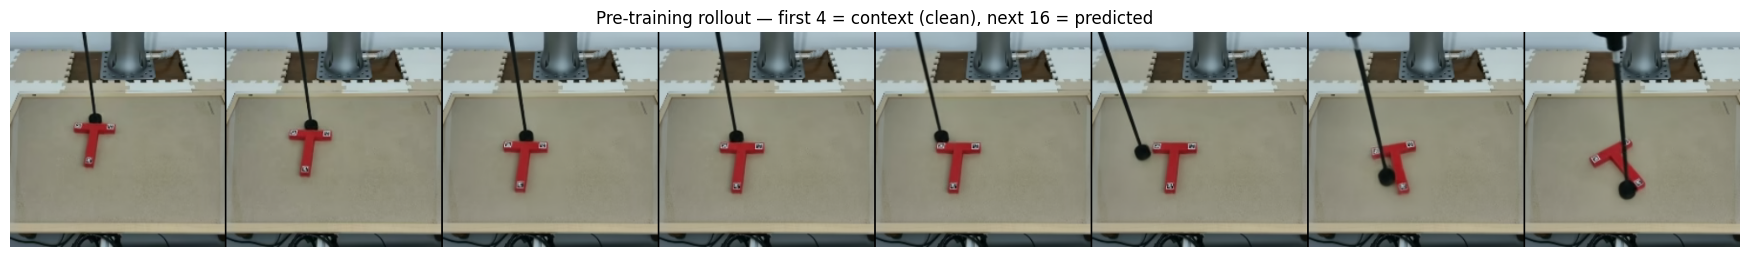

This browser does not support the video tag.


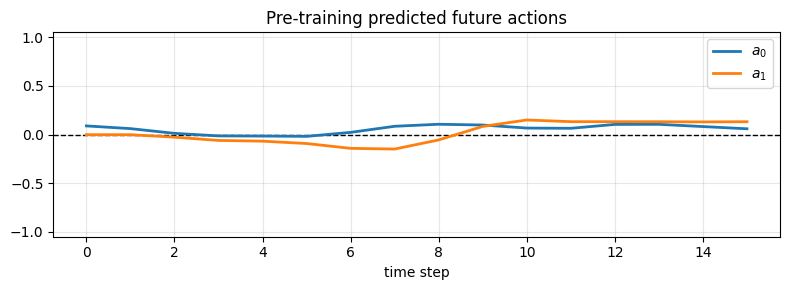

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import mediapy


def plotSnapshots(video, n_frames=8, border_width=2, figsize=None, title=None):
    T = video.shape[0]
    indices = np.linspace(0, T - 1, n_frames, dtype=int)
    frames = video[indices].cpu().permute(0, 2, 3, 1).to(torch.float32).numpy()
    frames = np.clip(frames * 255, 0, 255).astype(np.uint8)
    H, _, C = frames.shape[1], frames.shape[2], frames.shape[3]
    border = np.zeros((H, border_width, C), dtype=np.uint8)
    parts = []
    for i, f in enumerate(frames):
        if i > 0:
            parts.append(border)
        parts.append(f)
    strip = np.concatenate(parts, axis=1)
    fig, ax = plt.subplots(1, 1, figsize=figsize or (n_frames * 2.2, 2.6))
    ax.imshow(strip)
    if title:
        ax.set_title(title)
    ax.axis('off')
    plt.tight_layout()
    plt.show()


def plotActions(actions, title=None, figsize=(8, 3)):
    act = actions.cpu().float().numpy() if hasattr(actions, 'cpu') else np.array(actions)
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    for i in range(act.shape[-1]):
        ax.plot(act[:, i], linewidth=2, label=fr'$a_{i}$')
    ax.set_xlabel('time step')
    ax.set_ylim(-1.05, 1.05)
    if title:
        ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def plotVideo(video, fps=10):
    arr = (video.cpu().permute(0, 2, 3, 1).to(torch.float32).numpy() * 255).astype('uint8')
    mediapy.show_video(arr, fps=fps)


with torch.no_grad():
    full_latents = torch.cat([ctx_latents[:1], pred_obs[:1]], dim=1)
    img_full = tokenizer.decode(full_latents)[0].clamp(0, 1)

plotSnapshots(
    img_full, n_frames=min(8, T_CTX + NUM_PRED_STEPS),
    title=f'Pre-training rollout — first {T_CTX} = context (clean), next {NUM_PRED_STEPS} = predicted',
)
plotVideo(img_full)
plotActions(pred_act[0], title='Pre-training predicted future actions')

## Terminal loss

Same adversarial `½·mean(a²)` as the base notebook — minimising it pushes the policy toward zero-magnitude actions, which would ordinarily collapse the action head under full FT.

In [7]:
def terminal_loss(z_fut, a_fut):
    return 0.5 * (a_fut ** 2).mean()


L = terminal_loss(pred_obs, pred_act).item()
print(f"L = {L:.6f}")

L = 0.003658


## Discrete adjoint backward — LoRA-aware

Identical structure to the base notebook with one change: `params` is filtered to LoRA-trainable tensors. Calling `torch.autograd.grad` on frozen params just returns `None`, so the original code would still *work* — but it would also allocate ~700 MB of zero buffers for params we never touch. Filtering brings the buffer cost down to ~11 MB and skips the per-frozen-param `None`-checks.

Memory ordering of savings vs. the base notebook (Section 1):
- activation cache: unchanged (still one diffusion step at a time, the adjoint's job)
- per-step `out` tuple: shrinks from 229 entries to ~140 LoRA tensors
- per-step accumulated `grads` buffer: ~700 MB → ~11 MB
- post-step Adam optimiser state: not allocated yet, but ~1.4 GB → ~22 MB once we wire AdamW below

In [8]:
def adjoint_policy_grad(traj_z, traj_a, setup, loss_fn):
    z_N = traj_z[-1].detach().clone().requires_grad_(True)
    a_N = traj_a[-1].detach().clone().requires_grad_(True)
    L = loss_fn(z_N, a_N)
    lam_z, lam_a = torch.autograd.grad(L, [z_N, a_N], allow_unused=True)
    if lam_z is None: lam_z = torch.zeros_like(z_N)
    if lam_a is None: lam_a = torch.zeros_like(a_N)

    # only LoRA tensors get a grad buffer
    params = [p for p in denoiser.parameters() if p.requires_grad]
    grads = [torch.zeros_like(p) for p in params]

    alphas = setup["alphas"]
    for k in reversed(range(len(alphas))):
        alpha = alphas[k]
        z_in = traj_z[k].detach().clone().requires_grad_(True)
        a_in = traj_a[k].detach().clone().requires_grad_(True)

        z_hat_fut, a_hat_fut = denoiser_call(z_in, a_in, setup, k)

        out = torch.autograd.grad(
            [z_hat_fut, a_hat_fut],
            [z_in, a_in] + params,
            grad_outputs=[alpha * lam_z, alpha * lam_a],
            allow_unused=True,
        )
        grad_z_in, grad_a_in = out[0], out[1]
        grad_params = out[2:]

        lam_z = (1.0 - alpha) * lam_z + (grad_z_in if grad_z_in is not None else 0)
        lam_a = (1.0 - alpha) * lam_a + (grad_a_in if grad_a_in is not None else 0)

        for g, gp in zip(grads, grad_params):
            if gp is not None:
                g.add_(gp)

    return grads


t0 = time.time()
grads_adj = adjoint_policy_grad(traj_z, traj_a, setup, terminal_loss)
torch.cuda.synchronize()
print(f"adjoint backward: {time.time() - t0:.2f}s")
print(f"max |grad|: {max(g.abs().max().item() for g in grads_adj):.3e}")

adjoint backward: 2.28s
max |grad|: 3.442e-02


## Verification: autograd through the rollout (LoRA params only)

Same memory-heavy reference as the base notebook — autograd holds the activation cache for all `N` denoiser passes — but we ask for grads on LoRA tensors only. With `r=8` and `all-linear` targets, fp32 activations for `NUM_DIFFUSION_STEPS=4` fit comfortably and we should match the adjoint to ~`1e-6`.

In [ ]:
def autograd_policy_grad(setup, loss_fn):
    z_fut = setup["z_fut0"].clone()
    a_fut = setup["a_fut0"].clone()
    for k, alpha in enumerate(setup["alphas"]):
        z_hat_fut, a_hat_fut = denoiser_call(z_fut, a_fut, setup, k)
        z_fut = z_fut + alpha * (z_hat_fut - z_fut)
        a_fut = a_fut + alpha * (a_hat_fut - a_fut)
    L = loss_fn(z_fut, a_fut)
    trainable_params = [p for p in denoiser.parameters() if p.requires_grad]
    g = torch.autograd.grad(L, trainable_params, allow_unused=True)
    return [gi if gi is not None else torch.zeros_like(p)
            for gi, p in zip(g, trainable_params)], L.item()


t0 = time.time()
grads_naive, L_naive = autograd_policy_grad(setup, terminal_loss)
torch.cuda.synchronize()
print(f"autograd-through-rollout: {time.time() - t0:.2f}s")
print(f"L (autograd) = {L_naive:.6f}   L (forward) = {L:.6f}")

In [ ]:
trainable_pairs = [(n, p) for n, p in denoiser.named_parameters() if p.requires_grad]
items = []
for (name, p), ga, gn in zip(trainable_pairs, grads_adj, grads_naive):
    if gn.abs().max().item() == 0 and ga.abs().max().item() == 0:
        continue
    diff = (ga - gn).abs().max().item()
    nrm = gn.abs().max().item()
    rel = diff / max(nrm, 1e-12)
    items.append((nrm, name, diff, rel))
items.sort(reverse=True)

# Truncate names for display
def _shorten(name, max_len=70):
    if len(name) <= max_len:
        return name
    return "..." + name[-(max_len-3):]

print(f"{'param':70s}  {'|grad|max':>10s}  {'|adj-naive|':>11s}  {'rel err':>10s}")
print("-" * 108)
for nrm, name, diff, rel in items[:10]:
    print(f"{_shorten(name):70s}  {nrm:10.2e}  {diff:11.2e}  {rel:10.2e}")
print(f"\n{len(items)}/{len(grads_adj)} LoRA tensors received non-zero gradient")
print(f"Worst relative error: {max(it[3] for it in items):.2e}")

## Training loop — Adam on LoRA params, adjoint gradient

200 AdamW steps on the LoRA matrices only, using `adjoint_policy_grad` for the gradient. We use `lr=1e-4` (vs. `1e-5` in the full-FT base notebook) — LoRA initialises `B = 0`, so the adapter starts as a no-op and benefits from a more aggressive LR. We snapshot the LoRA state-dict at init so it can be reset to a no-op via `denoiser.load_state_dict(lora_state_init, strict=False)` if you re-run this cell.

In [11]:
torch.backends.cuda.enable_flash_sdp(True)
torch.backends.cuda.enable_mem_efficient_sdp(True)

# Snapshot LoRA state at init (B=0 → adapter = no-op). Reload to undo training.
lora_state_init = {n: p.detach().clone() for n, p in denoiser.named_parameters() if p.requires_grad}

LR = 1e-4
N_TRAIN_STEPS = 200

trainable = [p for p in denoiser.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(trainable, lr=LR)
losses = []

t0 = time.time()
for step in range(N_TRAIN_STEPS):
    # Fresh initial noise per step → optimiser sees a distribution of rollouts
    traj_z_t, traj_a_t, setup_t = policy_forward_with_traj(
        ctx_latents, ctx_actions, NUM_PRED_STEPS, NUM_DIFFUSION_STEPS
    )
    L_step = terminal_loss(traj_z_t[-1], traj_a_t[-1]).item()
    losses.append(L_step)

    grads = adjoint_policy_grad(traj_z_t, traj_a_t, setup_t, terminal_loss)

    optimizer.zero_grad(set_to_none=False)
    for p, g in zip(trainable, grads):
        p.grad = g
    optimizer.step()

    if step == 0 or (step + 1) % 1 == 0:
        print(f"step {step+1:3d}/{N_TRAIN_STEPS}  loss={L_step:.6f}  ({time.time()-t0:.1f}s)")

torch.cuda.synchronize()
print(f"\ntotal: {time.time()-t0:.1f}s   loss[0]={losses[0]:.6f}  loss[-1]={losses[-1]:.6f}")

plt.figure(figsize=(8, 3))
plt.plot(losses, linewidth=1.5)
plt.xlabel('gradient step')
plt.ylabel('terminal_loss')
plt.title(f'Training loss (AdamW on LoRA, lr={LR}, {N_TRAIN_STEPS} steps)')
plt.grid(alpha=0.3)
plt.yscale('log')
plt.tight_layout()
plt.show()

step   1/200  loss=0.001850  (3.5s)
step   2/200  loss=0.001712  (6.9s)
step   3/200  loss=0.001582  (10.4s)
step   4/200  loss=0.001543  (13.9s)
step   5/200  loss=0.001238  (17.4s)
step   6/200  loss=0.001150  (21.0s)
step   7/200  loss=0.001033  (24.6s)
step   8/200  loss=0.000841  (28.1s)
step   9/200  loss=0.000806  (31.7s)
step  10/200  loss=0.000694  (35.2s)
step  11/200  loss=0.000492  (38.8s)
step  12/200  loss=0.000409  (42.4s)
step  13/200  loss=0.000315  (45.9s)
step  14/200  loss=0.000286  (49.5s)
step  15/200  loss=0.000206  (53.1s)
step  16/200  loss=0.000175  (56.6s)
step  17/200  loss=0.000134  (60.2s)
step  18/200  loss=0.000138  (63.8s)
step  19/200  loss=0.000199  (67.4s)
step  20/200  loss=0.000151  (70.9s)
step  21/200  loss=0.000173  (74.5s)
step  22/200  loss=0.000139  (78.1s)
step  23/200  loss=0.000152  (81.7s)
step  24/200  loss=0.000099  (85.3s)
step  25/200  loss=0.000113  (88.9s)
step  26/200  loss=0.000069  (92.4s)
step  27/200  loss=0.000078  (96.0s)
ste

KeyboardInterrupt: 

## Post-training inference (adapter ON)

Re-render the same rollout visualizations with the trained LoRA adapter active. We replay `SEED_FWD` so the noise in the rollout is identical to the pre-training pass — any difference in `pred_act_post` vs `pred_act` is purely the LoRA delta. The action plot here should show *less* collapse than the full-FT post-training plot in the base notebook — that's the LoRA regularisation in action.

|a|_mean   pre-train: 0.0731   post-train (LoRA on): 0.0090
terminal_loss   pre-train: 0.003658   post-train (LoRA on): 0.000086


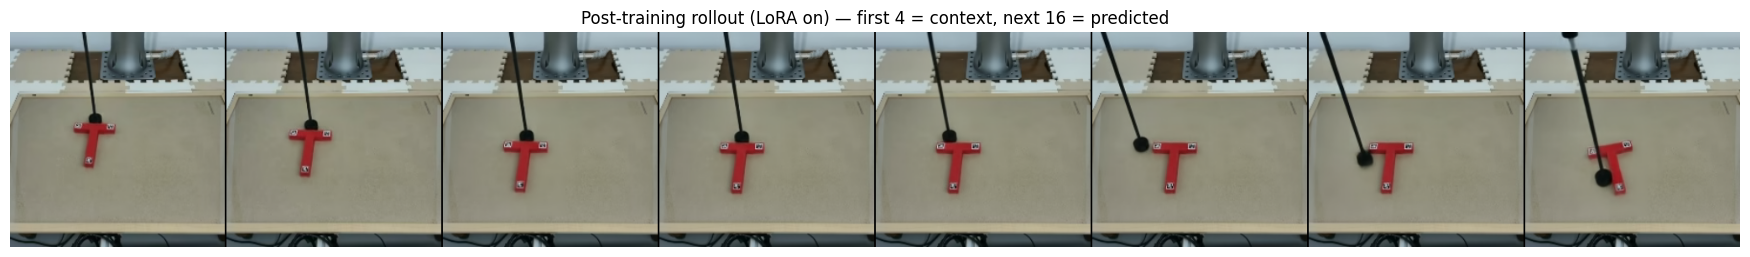

This browser does not support the video tag.


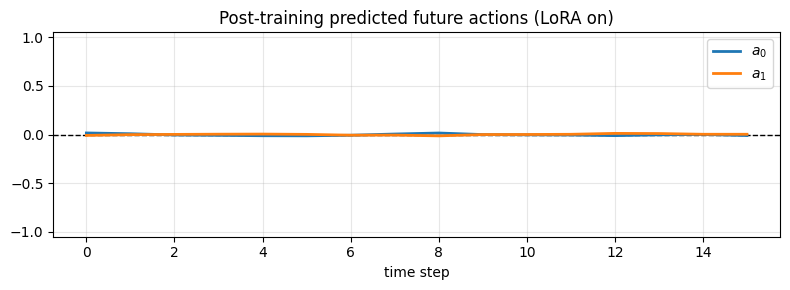

In [12]:
torch.manual_seed(SEED_FWD)
traj_z_post, traj_a_post, _ = policy_forward_with_traj(
    ctx_latents, ctx_actions, NUM_PRED_STEPS, NUM_DIFFUSION_STEPS
)
pred_obs_post = traj_z_post[-1]
pred_act_post = traj_a_post[-1]

print(f"|a|_mean   pre-train: {pred_act.abs().mean().item():.4f}   "
      f"post-train (LoRA on): {pred_act_post.abs().mean().item():.4f}")
print(f"terminal_loss   pre-train: {L:.6f}   "
      f"post-train (LoRA on): {terminal_loss(pred_obs_post, pred_act_post).item():.6f}")

with torch.no_grad():
    full_latents_post = torch.cat([ctx_latents[:1], pred_obs_post[:1]], dim=1)
    img_full_post = tokenizer.decode(full_latents_post)[0].clamp(0, 1)

plotSnapshots(
    img_full_post, n_frames=min(8, T_CTX + NUM_PRED_STEPS),
    title=f'Post-training rollout (LoRA on) — first {T_CTX} = context, next {NUM_PRED_STEPS} = predicted',
)
plotVideo(img_full_post)
plotActions(pred_act_post[0], title='Post-training predicted future actions (LoRA on)')

## Forgetting check — `disable_adapter()` recovers pretrained behavior bit-exact

Because LoRA is additive on a frozen base, disabling the adapter sets its contribution to exactly zero — the forward becomes the original frozen denoiser. Replaying `SEED_FWD` with `disable_adapter()` should yield predictions that match the pre-training rollout *to dtype precision*, regardless of how aggressively the adapter has been trained. This is a property full FT cannot give: once you've overwritten the base weights, you're done.

In [ ]:
torch.manual_seed(SEED_FWD)
with denoiser.disable_adapter():
    traj_z_dis, traj_a_dis, _ = policy_forward_with_traj(
        ctx_latents, ctx_actions, NUM_PRED_STEPS, NUM_DIFFUSION_STEPS
    )
pred_obs_dis = traj_z_dis[-1]
pred_act_dis = traj_a_dis[-1]

abs_diff_act = (pred_act - pred_act_dis).abs().max().item()
abs_diff_obs = (pred_obs - pred_obs_dis).abs().max().item()
print(f"max |pred_act_pre - pred_act_disabled|: {abs_diff_act:.3e}   (expected ~0)")
print(f"max |pred_obs_pre - pred_obs_disabled|: {abs_diff_obs:.3e}   (expected ~0)")
print()
print(f"|a|_mean   pre-train:           {pred_act.abs().mean().item():.4f}")
print(f"|a|_mean   post-train (on):     {pred_act_post.abs().mean().item():.4f}")
print(f"|a|_mean   post-train disabled: {pred_act_dis.abs().mean().item():.4f}  ← should match pre-train")

plotActions(pred_act_dis[0], title='Disabled-adapter actions (post-train) — should match pre-training exactly')

## Save / reload / merge

The adapter is a few MB on disk (LoRA matrices only, not the base weights). Standard PEFT lifecycle:

```python
# Save just the LoRA delta
denoiser.save_pretrained("./lora_adjoint_adapter")

# Reload onto a fresh base
from peft import PeftModel
base = load_denoiser(cfg, device).to(DTYPE).eval()
finetuned = PeftModel.from_pretrained(base, "./lora_adjoint_adapter")

# For deployment with the existing samplers — fold LoRA into W and unwrap
merged = finetuned.merge_and_unload()  # plain DenoiserWrapper, ready for unified_flowmatching_sampler
```

For "experiment with adapter / production without" workflows, keep the merged version separate so `disable_adapter()` remains available on the PEFT version.